In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [21]:
dataset = pd.read_csv('Mall_Customers.csv')
print(dataset.head())
X = dataset.iloc[:, [3, 4]].values
print(X)


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [

In [26]:
from sklearn.cluster import OPTICS

optics_clust = OPTICS( min_samples=4)
y_optics_clust = optics_clust.fit_predict(X)


unique, counts = np.unique(y_optics_clust, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(-1): np.int64(80), np.int64(0): np.int64(6), np.int64(1): np.int64(9), np.int64(2): np.int64(8), np.int64(3): np.int64(5), np.int64(4): np.int64(7), np.int64(5): np.int64(11), np.int64(6): np.int64(4), np.int64(7): np.int64(6), np.int64(8): np.int64(10), np.int64(9): np.int64(11), np.int64(10): np.int64(4), np.int64(11): np.int64(9), np.int64(12): np.int64(9), np.int64(13): np.int64(5), np.int64(14): np.int64(5), np.int64(15): np.int64(11)}


In [27]:
supervised=pd.DataFrame(dataset)

supervised['Cluster_group']=y_optics_clust

supervised


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,8
2,3,Female,20,16,6,9
3,4,Female,23,16,77,8
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


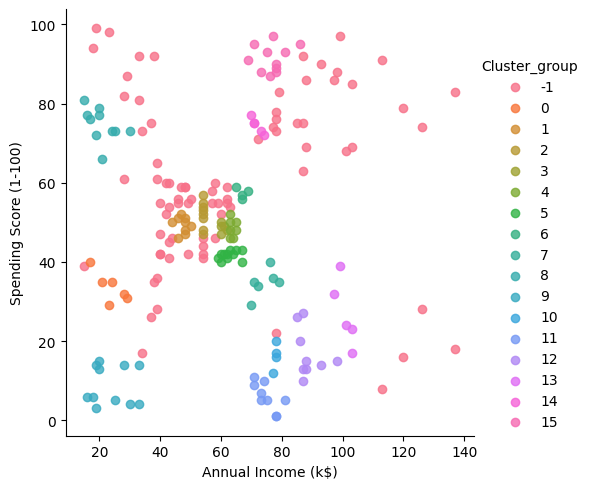

In [25]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True)
